In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import os

In [14]:
#Define features and target
FEATURES = [
    'hour', 'day_of_week', 'month', 'year', 'quarter',
    'is_weekend', 'is_rush_hour', 'is_night', 'Junction',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'lag_1h', 'lag_2h', 'lag_24h', 'lag_168h',
    'rolling_mean_3h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_7d'
 ]
TARGET = 'Vehicles'

# 1. Load the fully engineered dataset you saved at the end of Phase 4
df = pd.read_csv('../data/features/train_features.csv', parse_dates=['DateTime'])

# 2. Recreate the exact 80/20 split so we have our 'val' dataset back
split_date = df['DateTime'].quantile(0.8)
val = df[df['DateTime'] >= split_date]

# 3. Separate it into Features (X) and Target (y)
X_val = val[FEATURES]
y_val = val['Vehicles']

print(f"✅ Validation data loaded! (Shape: {val.shape})")

✅ Validation data loaded! (Shape: (9624, 28))


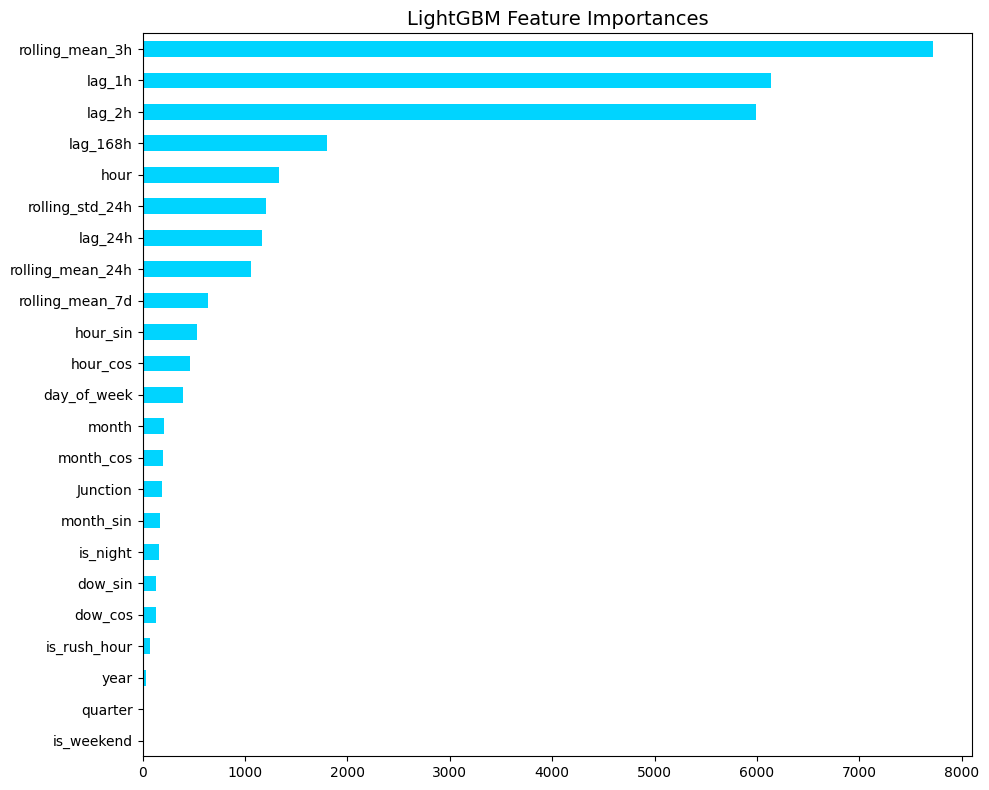

In [15]:
#Feature Importance
# This asks LightGBM Which features were most important in making predictions
lgb_model = joblib.load('../models/lightgbm_traffic_forecaster.pkl')
FEATURES = joblib.load('../models/feature_columns.pkl')

importances = pd.Series(lgb_model.feature_importances_, index=FEATURES)
importances.sort_values(ascending=True).plot(
    kind='barh', figsize=(10, 8), color='#00d4ff'
)
plt.title('LightGBM Feature Importances', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/09_feature_importance.png', dpi=150)
plt.show()

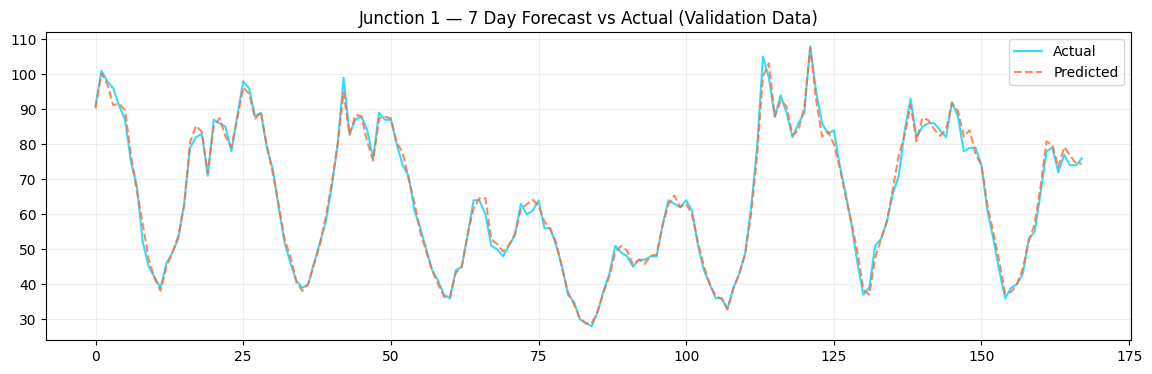

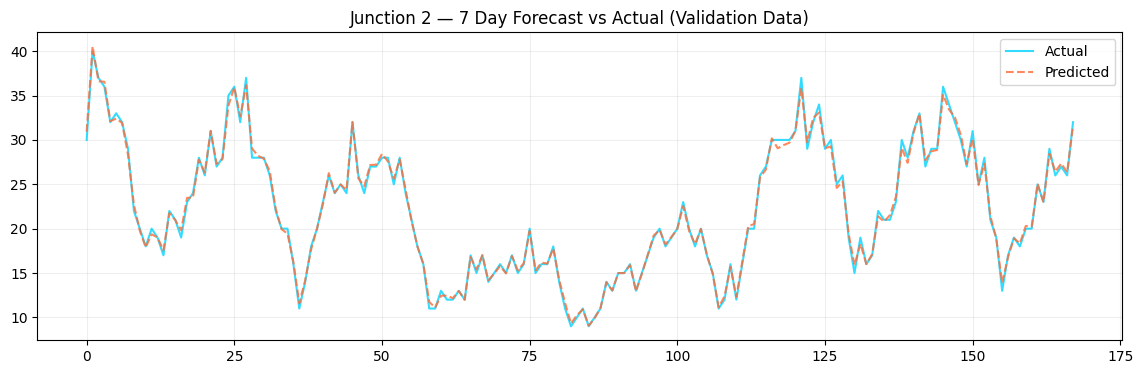

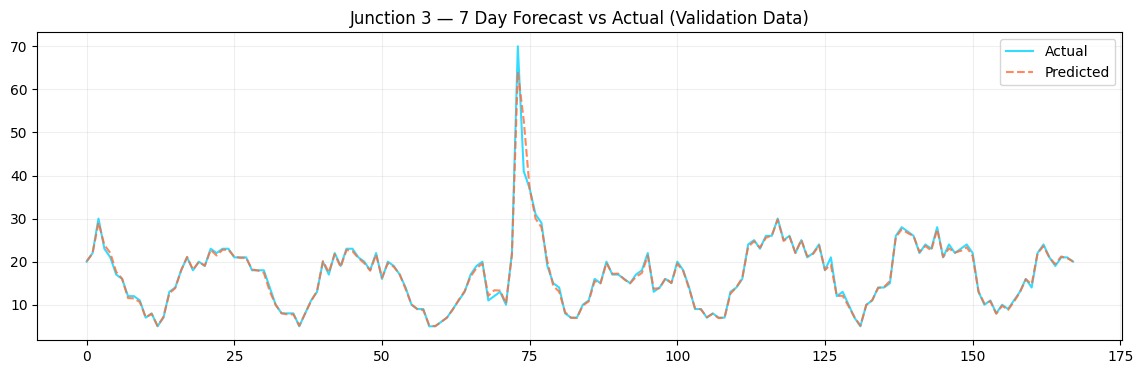

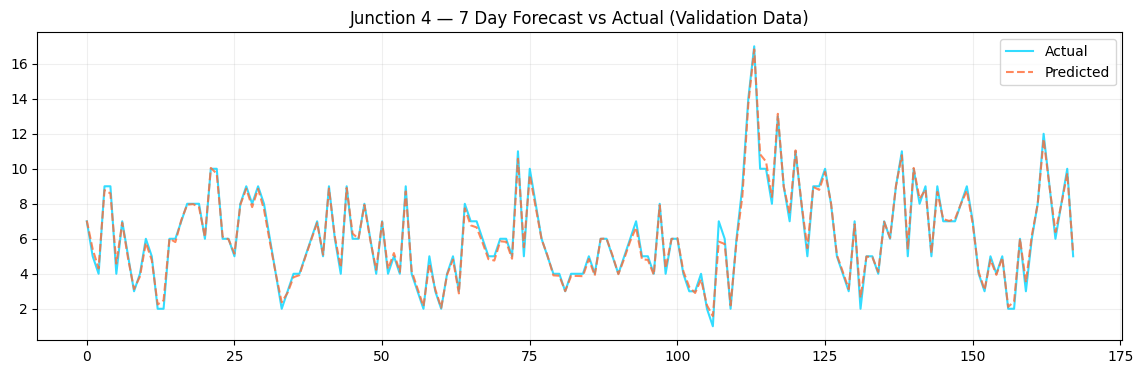

In [18]:
# ── 2. Actual vs Predicted Plot (Using Validation Set) ─
# We plot the first 168 hours (7 days) of the validation set to visually check accuracy
for j in [1, 2, 3, 4]:
    # Filter the validation data for the specific junction
    mask = val['Junction'] == j
    y_true = y_val[mask]
    y_pred = lgb_model.predict(X_val[mask])

    plt.figure(figsize=(14, 4))
    # Plot real traffic data
    plt.plot(y_true.values[:168], label='Actual', color='#00d4ff', alpha=0.8)
    # Plot what the model predicted
    plt.plot(y_pred[:168], label='Predicted', color='#ff6b35', alpha=0.8, linestyle='--')
    
    plt.title(f'Junction {j} — 7 Day Forecast vs Actual (Validation Data)')
    plt.legend()
    plt.grid(alpha=0.2)
    
    # Notice the 'f' string syntax is corrected here!
    plt.savefig(f'../reports/figures/10_junction{j}_forecast.png', dpi=150)
    plt.show()